# Physics-Informed Operator Learning with a Finite-Element Weak Form

*Training the same Fourier Neural Operator **without labelled solutions** — the finite-element weak-form residual supplies the supervision signal (a "Finite Operator Learning", FOL, approach).*

---

## 1. Why remove the labels?

In the previous chapter the operator was trained on FEM-computed targets $T_{n+1}^{\text{FEM}}$. Producing those targets is itself expensive, and the network can only ever be as good as the data it is shown. Here we take a different route: the network is supervised **directly by the governing physics**. No target field is provided to the training loop — only the discretized equation the prediction must satisfy.

This is the operator-learning analogue of a physics-informed neural network. Because we work from the finite-element (weak) form rather than the strong-form PDE, we call it a *finite-element weak-form residual loss*.

## 2. Governing equation

The physics is identical to the [data-driven chapter](FNO_transient_data_driven.ipynb) — transient, nonlinear, heterogeneous heat conduction:

$$\rho c_p \,\frac{\partial T}{\partial t} = \frac{\partial}{\partial x}\left( k(x,T)\,\frac{\partial T}{\partial x} \right), \qquad k(x,T)=\alpha(x)\bigl(0.5+T^2\bigr),$$

with $T(0,t)=1$, $T(1,t)=0$. After a backward-Euler step and finite-element assembly, one time step is the algebraic system

$$\underbrace{\bigl(M(T_{n+1})+\Delta t\,K(T_{n+1})\bigr)}_{\text{depends on the unknown }T_{n+1}}\,T_{n+1} \;=\; M(T_n)\,T_n .$$

This is genuinely implicit -- $k(x,T)$ is evaluated at the *unknown* $T_{n+1}$ -- so the FEM ground truth is solved with a few Newton-Raphson iterations per step, not a single linear solve.

## 3. The weak-form residual as a loss

Given the current field $T_n$ and material $\alpha$, the FNO predicts $\hat{T}_{n+1}$. We assemble the same mass and stiffness matrices and measure how far the prediction is from satisfying the discrete step through the **residual on the interior nodes**:

$$r \;=\; \bigl(M(\hat T_{n+1}) + \Delta t\,K(\hat T_{n+1})\bigr)\,\hat{T}_{n+1} \;-\; M(T_n)\,T_n .$$

Note $M,K$ here are assembled at the FNO's own prediction $\hat T_{n+1}$, matching the fully-implicit ground truth above. If $r=0$, the prediction is exactly the finite-element solution. This notebook uses the **weighted-residual (Galerkin) form** of the loss: the predicted interior field itself plays the role of the test function, and the residual is detached from the gradient so that back-propagation drives the discrete equation toward zero (without detaching it, the loss becomes a bilinear form the optimizer can exploit -- driving it negative without actually shrinking the residual). The raw form above trained fine in-distribution but let sharp/discontinuous snapshots dominate the batch gradient, since their residual is orders of magnitude larger than a calm snapshot's; the loss actually implemented is the **relative-L2, per-sample normalized** version, dividing by that same equation's own right-hand side so every sample contributes on equal footing regardless of physical scale:

$$\mathcal{L}_{\text{phys}} \;=\; \left\langle\, \frac{\hat{T}_{n+1}^{\text{int}} \cdot \operatorname{sg}(r)}{\lVert M(T_n)T_n\rVert^{2}_{\text{int}} + \epsilon} \,\right\rangle_{\text{batch}}, \qquad \epsilon = 10^{-8},$$

where $\operatorname{sg}(\cdot)$ is stop-gradient and the denominator is the same $M(T_n)T_n$ that already appears in $r$'s own right-hand side above -- no new quantity is introduced. The same normalization defines a non-negative **quality** metric, $\lVert r\rVert^2 / (\lVert M(T_n)T_n\rVert^2_{\text{int}}+\epsilon)$, used only for monitoring and validation (see below), never differentiated.

Crucially, **no ground-truth $T_{n+1}$ enters the optimizer, at training or validation time.** Both the training loss above and the held-out check used for early stopping are this same physics-only quantity -- there is no longer a separate FEM-labeled validation set anywhere in this notebook.

<div align="center">

<br><em style="color:#475569;font-size:0.9em">Figure 1. Physics-informed training: the finite-element weak-form residual replaces labelled targets as the supervision signal. (Schematic shows the unnormalized form for clarity; the implemented loss divides by &Vert;M(T&#8345;)T&#8345;&Vert;&sup2;+&epsilon; per sample -- see the equation above.)</em>
</div>

## 4. Architecture

The network is the identical FNO used in the [data-driven chapter](FNO_transient_data_driven.ipynb) (three input channels; four spectral layers of width 64; predicts $\dot T$, integrated with a masked explicit-Euler step). Only the *loss* changes — from a data-mismatch term to the physics residual above. This isolates the effect of the training signal while keeping the model fixed.

## 5. What to look for in the results

- **Convergence curve.** Both curves plotted are the same normalized physics quantity, not a labeled comparison: the training curve is $\mathcal{L}_{\text{phys}}$ on training batches, the second is the non-negative **quality** metric on held-out states. Since neither is measured against a true target, the real check on whether physics-only training is actually working comes from the rollout comparisons of Sections 9–11 against real FEM trajectories, not from this plot alone.
- **Rollout error, box plots, qualitative samples, and out-of-distribution scenarios** follow the same format as the [data-driven chapter](FNO_transient_data_driven.ipynb), so the two training strategies can be compared directly.

Training here also uses **early stopping**, on the validation physics-residual quality rather than a labeled data mismatch or a fixed epoch count, with the same 20000-epoch budget as the data-driven chapter.

> **Training pool: initial states only.** The operator is trained on the *first* transition of each trajectory only: the 800 training initial conditions $T_0$ with their materials $\alpha(x)$. It never sees a later state, and no ground-truth $T_1$ is read anywhere in training or validation. Both the loss and early stopping use the normalized physics residual. Every rollout step after the first is therefore extrapolation, which Sections 8–11 test directly.


**Shared ground truth.** Every transient chapter in this book reads its initial fields, materials and reference trajectories from one module, `fem_ground_truth.py`. A fixed pool of 1000 $(T_0,\alpha)$ fields (a Fourier-series / Gaussian-random-process / constant mixture, after Yamazaki et al. 2025, Sect. 3.3) is solved **once** with fully-implicit backward-Euler FEM (Newton–Raphson, exact Jacobian) on a fine mesh ($N=256$, $\Delta t=0.001$, $t\in[0,0.4]$). Each chapter then derives its own $(N,\Delta t)$ from that one solve by spatial interpolation and exact time sub-sampling, without re-solving. So every model is graded against the same converged answer, and not against a coarse solve that carries its own discretization error. The 1000 samples are split 800 / 100 / 100 (train / validation for early stopping / held-out test) identically in every chapter. Out-of-distribution scenarios come from the same module (50 unseen shapes solved once at $N=512$). Full details: [The Benchmark Problem](benchmark_problem.ipynb).

## 6. Training

The cell below loads the shared FEM reference, builds the training pool (800 initial states with their materials), trains the operator on the normalized weighted residual with early stopping on the validation residual quality, and saves the best checkpoint.

In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np
import os
import time

# fem_ground_truth.py lives next to this notebook; make sure it is importable
# regardless of the kernel's working directory (VS Code / Jupyter do not always
# default to the notebook's own folder).
import sys
_NB_DIR = os.path.abspath("")   # fem_ground_truth.py sits next to this notebook
if _NB_DIR not in sys.path:
    sys.path.insert(0, _NB_DIR)
from fem_ground_truth import (
    DEFAULT_DT, DEFAULT_RHO_CP, DEFAULT_NEWTON_ITERS,
    assemble_LM, solve_transient_fem_step, compute_weak_residual,
    fem_rollout, batch_fem_rollout,
    T0_GENERATOR_NAMES, generate_T0_alpha, t0_generator_choice,
)

# ==========================================
# 1. CONFIGURATION
# ==========================================
N_NODES = 64
N_GRID = N_NODES - 1  # 63 elements -- N_NODES is the primary quantity here, chosen as a power of 2 for the FNO's FFT-based spectral layers
WIDTH = 64
MODES = 4          # FAIR COMPARISON: matched across both notebooks so the networks are
                   # parameter-identical. 4 (not 8) because the training T0 distribution
                   # carries 99.5% of its perturbation energy in modes 1-3 and only 0.5%
                   # in modes 4-7 -- spectral weights above mode 3 are barely constrained
                   # by the loss, and on OOD input (HF-Rand carries 14% of its energy in
                   # modes 4-7) they pass high-frequency content through instead of
                   # damping it. See the OOD error map in Section 9.
BATCH_SIZE = 32
N_SAMPLES = 1000
TRAIN_SAMPLES = 800
# VAL_SAMPLES was 200, which left NOTHING past validation: N_SAMPLES ==
# TRAIN_SAMPLES + VAL_SAMPLES exactly, so every "test" partition below was
# really the validation set -- the same samples early stopping selected the
# checkpoint against. Every test number in Sections 6-8 was therefore
# optimistically biased. Split 800/100/100 instead (matching the PITI
# notebook), so ROLLOUT_TEST_START: is untouched by training AND by
# early stopping.
VAL_SAMPLES = 100                                   # held out from training, used only for early stopping
ROLLOUT_TEST_START = TRAIN_SAMPLES + VAL_SAMPLES    # remaining 100: never seen by training or early stopping
MAX_STEPS = 20
DT = DEFAULT_DT
RHO_CP = DEFAULT_RHO_CP
NEWTON_ITERS = DEFAULT_NEWTON_ITERS  # see fem_ground_truth.py for the solver itself
GRID = jnp.linspace(0, 1, N_NODES)

# Early stopping (no fixed epoch count): train up to MAX_EPOCHS, stopping sooner if
# held-out validation MSE stalls/worsens for PATIENCE consecutive checks.
MAX_EPOCHS = 20000
CHECK_EVERY = 200
PATIENCE = 15


# ==========================================
# 2. PHYSICS & WEAK FORM RESIDUALS
# ==========================================
# The in-distribution T0/alpha sample generator (Fourier/GRF/constant
# mixture, Yamazaki et al. 2025 Sect. 3.3) now lives in fem_ground_truth.py
# (imported above) alongside the FEM solver it feeds, so both are reusable
# from any notebook without copy-pasting.


# NOTE: the FEM assembly/solver/rollout (assemble_LM, solve_transient_fem_step,
# compute_weak_residual, fem_rollout, batch_fem_rollout) used to be defined inline
# here. They now live in fem_ground_truth.py (imported above) so any notebook can
# reuse the same ground-truth generator by importing it instead of copy-pasting.

# ==========================================
# 3. FOURIER NEURAL OPERATOR (MODEL)
# ==========================================
def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_norm, T_curr):
    # Predicts the time-derivative T-dot, not the raw increment; one explicit-Euler
    # step of size DT turns that rate into the next state: T_next = T_curr + DT*Tdot.
    # Resolution-generic: mask is built from T_curr.shape, not the global N_NODES
    # (previously hardcoded here, which would silently break/shape-mismatch on any
    # input length other than the training resolution) -- spectral_layer and the
    # pointwise dense layers were already resolution-agnostic. Needed for Section 10.
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i+1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    T_dot = (jnp.dot(x, params[12]) + params[13]).squeeze()
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, T_curr.shape[0]))
    return T_curr + DT * (T_dot * mask)

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH),
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p

# ==========================================
# 4. DATA PIPELINE PREPARATION -- T0 -> T1 ONLY
#    Training reads only T0 and alpha (weighted_residual_losses never uses a
#    ground-truth T1 -- see Section 3's markdown), so no Newton-Raphson
#    time-stepping happens here at all.
#
#    FIXED: T0/alpha used to be generated fresh at N_NODES=64 via
#    generate_T0_alpha, while Section 7 graded the resulting model against the
#    N=256 fine reference trajectory. Those are NOT the same problem for every
#    sample: generate_grf_fn Cholesky-factorizes a covariance built ON THE MESH
#    ITSELF, so the same PRNG key at N=256 and at N=64 produces two UNRELATED
#    random fields (the Fourier and constant branches are analytic in x and do
#    resample consistently). The cached pool records 496/1000 samples from the
#    GRF branch for T0, and alpha is drawn from the same mixture -- so roughly
#    three quarters of all samples were being graded against the FEM trajectory
#    of a different field than the one the network was actually given.
#
#    The pool was written with seed_k=42 / seed_t=7 / n_samples=1000 -- the very
#    seeds this cell used to call generate_T0_alpha with -- so sourcing T0/alpha
#    from the pool instead keeps sample indices aligned with every earlier run,
#    and makes "the input matches the ground truth" true by construction rather
#    than by coincidence. resample_field interpolates with jnp.interp and the
#    target grid includes both endpoints, so the hard Dirichlet pins
#    T0[0]=1, T0[-1]=0 survive the 256 -> 64 resampling exactly.
#
#    Loading the reference here rather than in Section 7 means the 825 MB
#    fine_reference.npz is read before training starts instead of after; it is
#    the same single load either way (Section 7 now reuses fem_dataset).
# ==========================================
from fem_ground_truth import get_reference_trajectory, derive_dataset

# Anchored to the notebook's own folder rather than the kernel's cwd, for the
# same reason _NB_DIR above is absolute.
_CKPT_DIR = os.path.join(_NB_DIR, "checkpoints")
POOL_PATH = os.path.join(_CKPT_DIR, "field_pool.npz")
REFERENCE_PATH = os.path.join(_CKPT_DIR, "fine_reference.npz")

print("Loading T0/alpha from the cached fine field pool (no FEM time-stepping needed for training)...")
reference_data = get_reference_trajectory(REFERENCE_PATH, POOL_PATH, dt_ref=0.001, steps_ref=400)
fem_dataset = derive_dataset(reference_data, n_nodes_target=N_NODES, dt_target=DT)

all_T0 = jnp.asarray(fem_dataset["T0"])
all_Alpha = jnp.asarray(fem_dataset["alpha"])

# Provenance of each sample's T0 (which of the 3 generators produced it), used
# to label test samples in the evaluation plots below and in the T0 diversity
# preview -- purely diagnostic, does not feed back into training or the data.
# Read straight off the pool now (authoritative) instead of replaying
# t0_generator_choice on locally-regenerated keys.
all_T0_generator = np.asarray(reference_data["generator"])

X_train_flat = jnp.stack([all_T0[:TRAIN_SAMPLES], all_Alpha[:TRAIN_SAMPLES],
                           jnp.tile(GRID, (TRAIN_SAMPLES, 1))], axis=-1)
X_val_flat = jnp.stack([all_T0[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES],
                         all_Alpha[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES],
                         jnp.tile(GRID, (VAL_SAMPLES, 1))], axis=-1)

# Normalization parameters based on training features
x_mean, x_std = X_train_flat.mean(axis=(0, 1)), X_train_flat.std(axis=(0, 1)) + 1e-7
X_train_norm = (X_train_flat - x_mean) / x_std
X_val_norm = (X_val_flat - x_mean) / x_std
print(f"training pairs: {X_train_flat.shape[0]} (T0->T1 only) | val: {X_val_flat.shape[0]} "
      f"| {N_SAMPLES - ROLLOUT_TEST_START} samples held out for Sections 6-8 rollout")

# ==========================================
# 5. PHYSICS-INFORMED LOSS & TRAINING (EARLY STOPPING)
# ==========================================
def make_opt(max_epochs):
    sched = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=max_epochs, alpha=1e-2)
    return optax.adamw(learning_rate=sched, weight_decay=1e-4)

REL_EPS = 1e-8   # floor against division by ~0 for near-equilibrium snapshots

def weighted_residual_losses(params, T_curr, alpha, x_norm):
    """Per-sample RELATIVE-L2 weighted residual, normalized like the PITI notebook
    (fno_piti_physics_dualdt_ablation_noLC.ipynb): dividing by the RHS's own squared
    norm keeps sharp/discontinuous snapshots from dominating the gradient just because
    their raw residual magnitude happens to be larger -- every sample contributes on
    equal footing regardless of physical scale. Returns (signed loss term used for the
    gradient, non-negative quality used only for monitoring)."""
    T_next_pred = fno_model(params, x_norm, T_curr)
    residual = compute_weak_residual(T_next_pred, T_curr, alpha)
    rhs_free = assemble_LM(T_curr, alpha)[1][1:-1]            # same RHS used inside compute_weak_residual
    denom = jnp.sum(rhs_free ** 2) + REL_EPS
    residual_detached = jax.lax.stop_gradient(residual)
    T_next_free = T_next_pred[1:-1]
    L_pde = jnp.sum(T_next_free * residual_detached) / denom  # signed, drives the gradient
    pde_quality = jnp.sum(residual ** 2) / denom               # non-negative, monitoring only
    return L_pde, pde_quality

@jax.jit
def val_residual_norm(p):
    """Mean RELATIVE physics-residual quality on validation (non-negative,
    normalized the same way as the training loss above). This is now the ONLY
    validation signal in the whole notebook -- no ground-truth T1 is read
    anywhere in training or validation; early stopping is decided purely by
    physics, matching the "no labelled data" framing in Section 1's markdown."""
    T_curr = X_val_flat[:, :, 0]; alpha = X_val_flat[:, :, 1]
    _, pde_quality = jax.vmap(weighted_residual_losses, (None, 0, 0, 0))(p, T_curr, alpha, X_val_norm)
    return jnp.mean(pde_quality)

def train_early_stop(max_epochs):
    params = init_params(jax.random.PRNGKey(123))
    opt = make_opt(max_epochs); opt_state = opt.init(params)

    @jax.jit
    def step(p, opt_s, b_X_norm, b_X_raw):
        T_curr_batch = b_X_raw[:, :, 0]
        alpha_batch = b_X_raw[:, :, 1]
        def loss_fn(p):
            # NORMALIZED WEIGHTED RESIDUAL (relative-L2, PITI-style): each sample's
            # residual is divided by its own RHS magnitude before averaging, so a few
            # sharp/discontinuous snapshots can no longer dominate the batch gradient
            # just by having a larger raw residual scale (see weighted_residual_losses
            # above, and the PITI notebook's Section 2 markdown for the derivation).
            L_pde, _ = jax.vmap(weighted_residual_losses, (None, 0, 0, 0))(p, T_curr_batch, alpha_batch, b_X_norm)
            return jnp.mean(L_pde)
        l, g = jax.value_and_grad(loss_fn)(p)
        u, opt_s = opt.update(g, opt_s, p)
        return optax.apply_updates(p, u), opt_s, l

    loss_history, res_history, epochs_recorded = [], [], []
    best_val, best_params, best_epoch, stall = jnp.inf, params, 0, 0
    for i in range(max_epochs):
        idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, X_train_flat.shape[0])
        params, opt_state, loss = step(params, opt_state, X_train_norm[idx], X_train_flat[idx])
        if i % CHECK_EVERY == 0:
            r = float(val_residual_norm(params))
            loss_history.append(float(loss)); res_history.append(r); epochs_recorded.append(i)
            improved = r < best_val
            if i % 1000 == 0:
                print(f"Epoch {i:5d} | Train Weighted-Res: {loss:.6e} | Val Residual Quality: {r:.6e}" + ("  * best" if improved else ""))
            if improved:
                best_val, best_params, best_epoch, stall = r, params, i, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    print(f"Early-stopped at epoch {i} (best val {best_val:.3e} @ epoch {best_epoch})")
                    break
    else:
        print(f"Hit max_epochs={max_epochs} without early stopping (best val {best_val:.3e} @ epoch {best_epoch})")
    return best_params, loss_history, res_history, epochs_recorded

print(f"Training for up to {MAX_EPOCHS} epochs using self-supervised weak-form residuals, with early stopping...")
_t0 = time.perf_counter()
params, loss_history, res_history, epochs_recorded = train_early_stop(MAX_EPOCHS)
jax.block_until_ready(params)   # JAX is async -- without this we would time dispatch, not training
wr_train_time = time.perf_counter() - _t0
wr_epochs_run = int(epochs_recorded[-1]) if epochs_recorded else 0
print(f"training wall-clock: {wr_train_time:.1f}s over {wr_epochs_run} epochs "
      f"({1000*wr_train_time/max(wr_epochs_run,1):.2f} ms/epoch)")

os.makedirs("checkpoints", exist_ok=True)
# New filename: this run's training INPUT changed (pool-sourced T0/alpha), so its
# weights are not comparable with params_wres_T0only_unsupervised.npz -- that
# checkpoint is left in place for reference rather than overwritten.
np.savez(os.path.join(_CKPT_DIR, "params_wres_T0only_poolsourced.npz"), *[np.asarray(pi) for pi in params])
print("Saved best-checkpoint params to checkpoints/params_wres_T0only_poolsourced.npz "
      "(fully label-free, and now trained on the same fields the ground truth was solved from)")

# ==========================================
# 6. TIME ROLLOUT EVALUATION
# ==========================================
# Sample picked from the genuinely held-out range (ROLLOUT_TEST_START:), not
# from validation. With the old 800/200 split there was no such range -- the
# index used here landed in the validation set that early stopping had already
# selected on.
test_idx = ROLLOUT_TEST_START + 5
T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]
print(f"Section 6 test sample (index {test_idx}) T0 generator: {T0_GENERATOR_NAMES[all_T0_generator[test_idx]]}")

def rollout_fno(p, T_init, alpha_prof, steps):
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, GRID], axis=-1) - x_mean) / x_std
        T_next = fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

def rollout_fno_res(p, T_init, alpha_prof, grid_local, steps):
    """Same as rollout_fno but takes an explicit grid array instead of closing
    over the global GRID, so it works at any resolution -- used by Section 10's
    super-resolution OOD test. x_mean/x_std are resolution-independent scalars
    (one number per channel, already averaged over nodes in Section 4), so they
    carry over unchanged to other resolutions."""
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, grid_local], axis=-1) - x_mean) / x_std
        T_next = fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

# Ground truth read from the SAME derived reference Section 7 grades against,
# instead of a fresh fem_rollout at N_NODES=64. The fresh solve carried N=64's
# own spatial discretization error while Section 7 carried the N=256
# reference's -- so this plot and the box plots were being measured against two
# different targets.
true_traj = jnp.asarray(fem_dataset["trajectory"])[test_idx, :MAX_STEPS]
fno_traj = jnp.vstack([T0_test, rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)])
abs_error = jnp.abs(true_traj - fno_traj)


Loading T0/alpha from the cached fine field pool (no FEM time-stepping needed for training)...


training pairs: 800 (T0->T1 only) | val: 100 | 100 samples held out for Sections 6-8 rollout
Training for up to 20000 epochs using self-supervised weak-form residuals, with early stopping...


Epoch     0 | Train Weighted-Res: 3.980626e-01 | Val Residual Quality: 2.072092e-02  * best


Epoch  1000 | Train Weighted-Res: 6.910485e-02 | Val Residual Quality: 1.456692e-03


Epoch  2000 | Train Weighted-Res: -3.294206e-02 | Val Residual Quality: 1.142661e-03  * best


Epoch  3000 | Train Weighted-Res: -6.023932e-04 | Val Residual Quality: 1.099473e-03


Epoch  4000 | Train Weighted-Res: 1.376850e-02 | Val Residual Quality: 1.053051e-03


Epoch  5000 | Train Weighted-Res: 7.496216e-03 | Val Residual Quality: 9.071293e-04


Epoch  6000 | Train Weighted-Res: 7.355510e-02 | Val Residual Quality: 7.959680e-04  * best


Epoch  7000 | Train Weighted-Res: -2.840950e-02 | Val Residual Quality: 7.938353e-04


Epoch  8000 | Train Weighted-Res: 2.011664e-02 | Val Residual Quality: 6.961678e-04  * best


Epoch  9000 | Train Weighted-Res: 2.553427e-02 | Val Residual Quality: 6.577578e-04  * best


Epoch 10000 | Train Weighted-Res: 2.786052e-02 | Val Residual Quality: 6.097756e-04  * best


Epoch 11000 | Train Weighted-Res: -4.933980e-03 | Val Residual Quality: 5.799750e-04


Epoch 12000 | Train Weighted-Res: 3.300493e-03 | Val Residual Quality: 5.839518e-04


Epoch 13000 | Train Weighted-Res: -2.264675e-02 | Val Residual Quality: 5.518224e-04


Epoch 14000 | Train Weighted-Res: -1.178715e-02 | Val Residual Quality: 5.091323e-04


Epoch 15000 | Train Weighted-Res: 1.044792e-02 | Val Residual Quality: 4.864956e-04


Epoch 16000 | Train Weighted-Res: -3.688780e-03 | Val Residual Quality: 4.670508e-04  * best


Epoch 17000 | Train Weighted-Res: -6.610610e-04 | Val Residual Quality: 4.736428e-04


Epoch 18000 | Train Weighted-Res: 1.957102e-02 | Val Residual Quality: 4.462132e-04


Epoch 19000 | Train Weighted-Res: 5.736412e-03 | Val Residual Quality: 4.394557e-04  * best


Hit max_epochs=20000 without early stopping (best val 4.395e-04 @ epoch 19000)
training wall-clock: 218.7s over 19800 epochs (11.04 ms/epoch)
Saved best-checkpoint params to checkpoints/params_wres_T0only_poolsourced.npz (fully label-free, and now trained on the same fields the ground truth was solved from)
Section 6 test sample (index 905) T0 generator: Gaussian random process


## 7. Training data: diversity of the initial fields

Before looking at training results, a quick check on what the network actually sees as input: examples of the initial-temperature field $T_0$ drawn from each of the three paper-matched generators (Fourier series, Gaussian random process, constant field), analogous to Fig. 8 of Yamazaki et al. (2025). All curves satisfy the hard Dirichlet BCs $T(0)=1,\,T(1)=0$ by construction (the perturbation from each generator is masked to vanish at the boundaries before being added to the linear ramp).

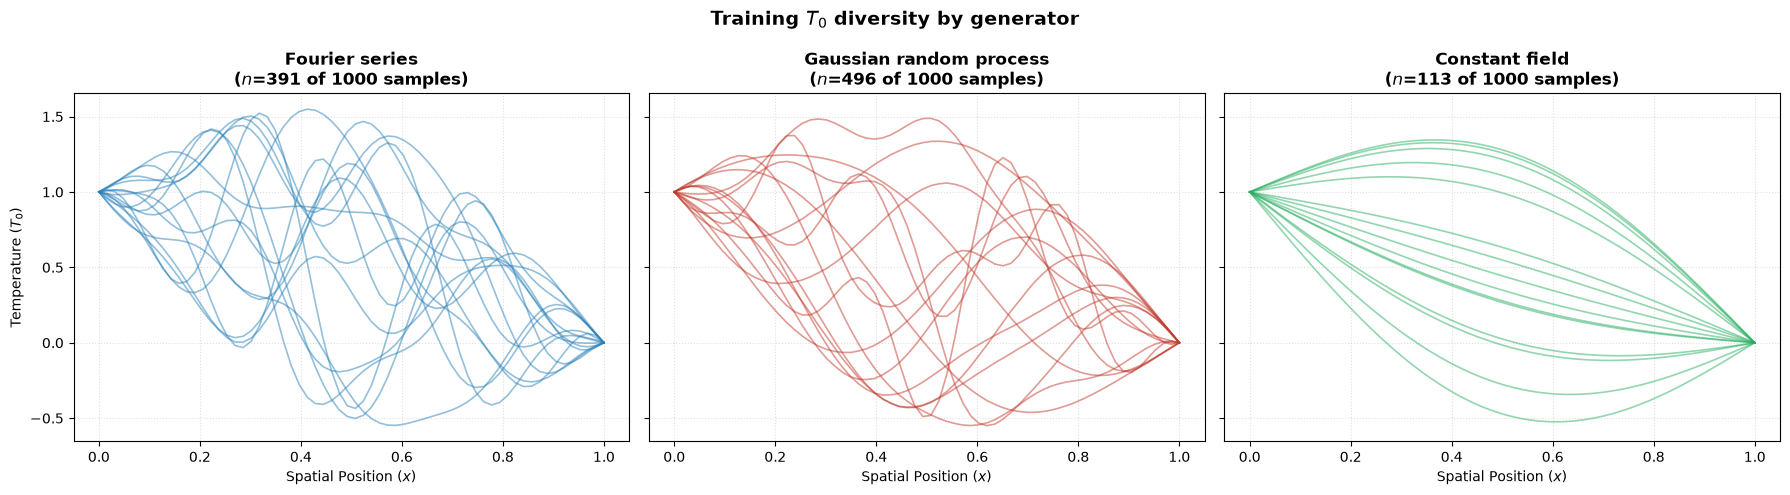

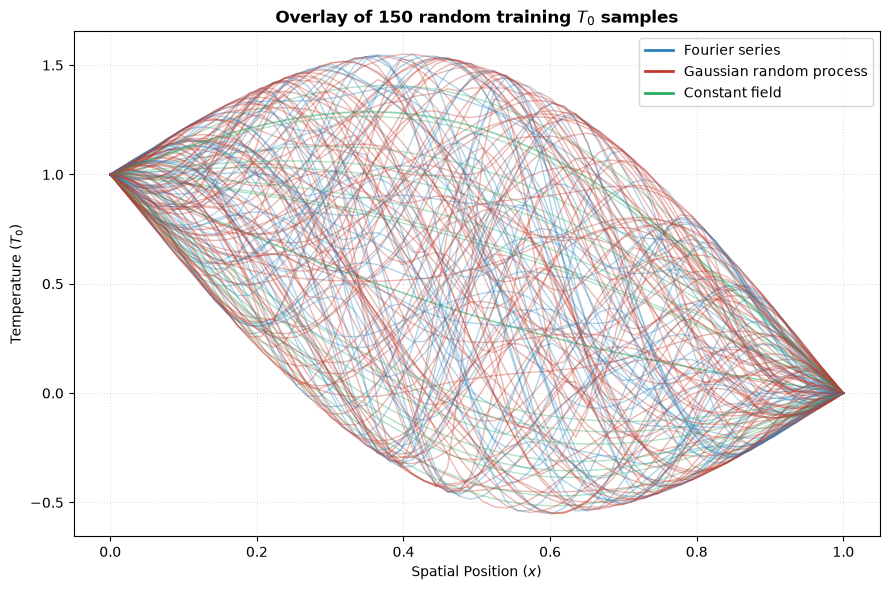

In [2]:
# ==========================================
# TRAINING DATA PREVIEW -- T0 SAMPLE DIVERSITY
# ==========================================
# Reuses all_T0_generator / T0_GENERATOR_NAMES computed above (right after
# all_T0) so the labeling here is guaranteed consistent with what Section 6's
# and Section 8's test-sample labels use -- no separate/duplicated logic.
gen_choice = all_T0_generator
gen_names = T0_GENERATOR_NAMES
gen_colors = ["#2980b9", "#c0392b", "#27ae60"]
rng_plot = np.random.default_rng(0)

# --- Panel per generator: a handful of example T0 curves from each family ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for gi, (name, color) in enumerate(zip(gen_names, gen_colors)):
    idx_pool = np.where(gen_choice == gi)[0]
    show_idx = rng_plot.choice(idx_pool, size=min(15, len(idx_pool)), replace=False)
    for j in show_idx:
        axes[gi].plot(GRID, all_T0[j], color=color, alpha=0.5, lw=1.2)
    axes[gi].set_title(f"{name}\n($n$={len(idx_pool)} of {N_SAMPLES} samples)", fontweight='bold')
    axes[gi].set_xlabel("Spatial Position ($x$)")
    axes[gi].grid(True, linestyle=':', alpha=0.4)
axes[0].set_ylabel("Temperature ($T_0$)")
fig.suptitle("Training $T_0$ diversity by generator", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Overlay view: many T0 samples together, colored by generator, for overall coverage ---
fig2, ax = plt.subplots(figsize=(9, 6))
show_all = rng_plot.choice(N_SAMPLES, size=150, replace=False)
for j in show_all:
    gi = int(gen_choice[j])
    ax.plot(GRID, all_T0[j], color=gen_colors[gi], alpha=0.35, lw=1.0)
handles = [plt.Line2D([0], [0], color=c, lw=2, label=n) for n, c in zip(gen_names, gen_colors)]
ax.legend(handles=handles, loc='upper right')
ax.set_title("Overlay of 150 random training $T_0$ samples", fontweight='bold')
ax.set_xlabel("Spatial Position ($x$)")
ax.set_ylabel("Temperature ($T_0$)")
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Convergence and prediction error

The normalized weighted-residual training loss (solid) is plotted against the normalized validation physics-residual quality (also solid, label-free), followed by a space-time map of the absolute error for one held-out trajectory.

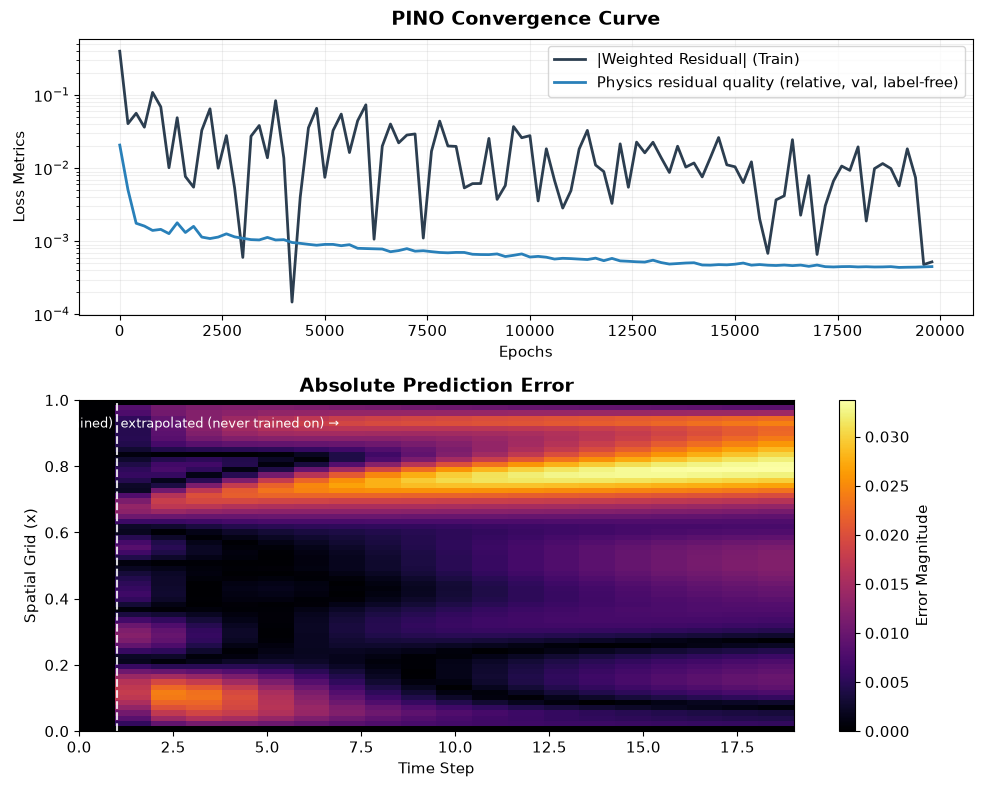

In [3]:
# ==========================================
# 7. POST-PROCESSING VISUALIZATION
# ==========================================
plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

# Plot 0: Convergence Curve
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(epochs_recorded, np.abs(loss_history), color='#2c3e50', lw=2, label='|Weighted Residual| (Train)')
ax0.plot(epochs_recorded, res_history, color='#2980b9', lw=2, label='Physics residual quality (relative, val, label-free)')
ax0.set_yscale('log')
ax0.set_title("PINO Convergence Curve", fontweight='bold', fontsize=14, pad=10)
ax0.set_xlabel("Epochs")
ax0.set_ylabel("Loss Metrics")
ax0.grid(True, which="both", ls="-", alpha=0.2)
ax0.legend(loc='upper right')

# Plot 1: Absolute Error
# Time step 0->1 is the ONLY transition the network was trained on (T0-only
# variant); everything from step 1 onward is autoregressive rollout into
# territory the physics residual was never optimized against. The dashed
# line marks that boundary so the two regimes aren't read as equally "seen".
ax1 = fig.add_subplot(gs[1, 0])
im1 = ax1.imshow(abs_error.T, aspect='auto', origin='lower', cmap='inferno', extent=[0, MAX_STEPS-1, 0, 1])
ax1.axvline(x=1, color='white', linestyle='--', lw=1.5, alpha=0.85)
ax1.text(0.9, 0.95, 'T0→T1 (trained)', color='white', fontsize=9, va='top', ha='right')
ax1.text(1.1, 0.95, 'extrapolated (never trained on) →', color='white', fontsize=9, va='top', ha='left')
ax1.set_title("Absolute Prediction Error", fontweight='bold', fontsize=14)
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Spatial Grid (x)")
fig.colorbar(im1, ax=ax1, label="Error Magnitude")

plt.tight_layout()
plt.show()

## 9. Error growth over the rollout

Spatial-error distributions per time step, for training and unseen test trajectories, showing how the physics-trained operator behaves under autoregressive rollout.

Computing full rollout errors for all samples...


inference: 135.24 ms for 100 samples x 19 steps (71.2 us per step per sample) | JIT compile 0.94s
saved compare_wr.npz  (mean MAE at final step: 1.5751e-02)


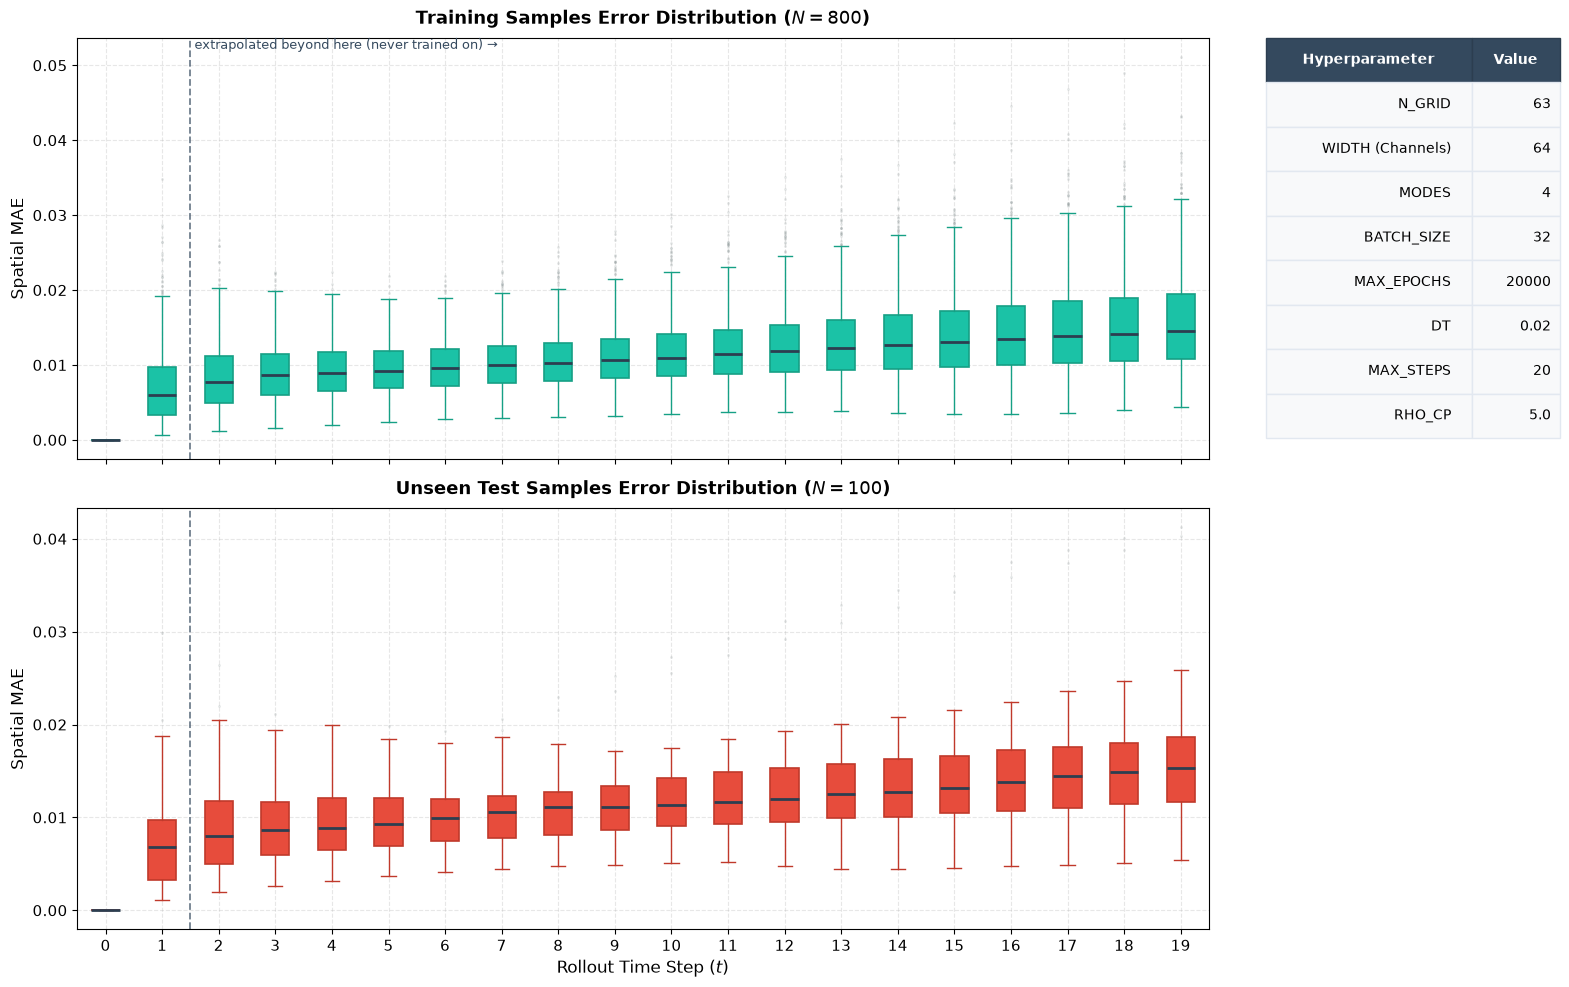

In [4]:
# =====================================================================
# 1. COMPUTE BATCHED ROLLOUT ERRORS (TRAIN vs TEST)
# =====================================================================
print("Computing full rollout errors for all samples...")

@jax.jit(static_argnums=(3,))
def batch_rollout_fno(p, T0_batch, alpha_batch, steps):
    """Performs autoregressive rollout for an entire batch of trajectories."""
    def step(T_curr, _):
        grid_b = jnp.tile(GRID, (T0_batch.shape[0], 1))
        x_raw = jnp.stack([T_curr, alpha_batch, grid_b], axis=-1)
        x_norm = (x_raw - x_mean) / x_std
        T_next = jax.vmap(fno_model, (None, 0, 0))(p, x_norm, T_curr)
        return T_next, T_next

    _, traj = jax.lax.scan(step, T0_batch, None, length=steps)
    traj = jnp.transpose(traj, (1, 0, 2))
    return jnp.concatenate([T0_batch[:, None, :], traj], axis=1)

# Ground truth for every sample, from the universal fine-mesh reference solved
# ONCE on the GPU (fem_universal_reference_precompute.py: N=256, dt=0.001, 400
# steps, float64) instead of re-solving FEM fresh at this notebook's own
# N_NODES=64. get_reference_trajectory loads that already-solved trajectory
# (no re-solving -- it is read from disk); derive_dataset then interpolates it
# down to (N_NODES, DT) and time-subsamples via exact stride, so this ground
# truth carries only the fine mesh's own (tiny) discretization error instead of
# a fresh, resolution-specific one from solving directly at N_NODES=64.
#
# reference_data / fem_dataset are loaded ONCE in Section 4 and reused here --
# not re-derived -- so the fields the network trained on and the trajectories
# graded below are provably the same FEM solve.
#
# The CAVEAT that used to sit here (all_T0/all_Alpha generated fresh at N=64 vs.
# a pool built at N=256, which the mesh-dependent GRF branch made into two
# unrelated fields for ~half the samples) is FIXED: Section 4 now sources
# all_T0/all_Alpha from this same reference via derive_dataset.
# derive_dataset's dt=0.02 stride covers steps 0..20 (t=0..0.4, 21 states); this
# notebook only trained/rolls out to MAX_STEPS-1=19 steps (t=0..0.38, 20 states)
# -- trim the one extra state so shapes match pred_train/pred_test below.
true_traj_all = jnp.asarray(fem_dataset["trajectory"])[:, :MAX_STEPS, :]
true_train = true_traj_all[:TRAIN_SAMPLES]
# The test partition starts at ROLLOUT_TEST_START, NOT at TRAIN_SAMPLES: samples
# TRAIN_SAMPLES:ROLLOUT_TEST_START are the validation set early stopping picked
# the checkpoint with, so including them here would report a validation score as
# a test score.
true_test = true_traj_all[ROLLOUT_TEST_START:]

# Generate FNO predictions
pred_train = batch_rollout_fno(params, all_T0[:TRAIN_SAMPLES], all_Alpha[:TRAIN_SAMPLES], MAX_STEPS-1)
pred_test  = batch_rollout_fno(params, all_T0[ROLLOUT_TEST_START:], all_Alpha[ROLLOUT_TEST_START:], MAX_STEPS-1)

# Calculate Mean Absolute Error across spatial nodes per time step
spatial_mae_train = jnp.mean(jnp.abs(true_train - pred_train), axis=2)
spatial_mae_test  = jnp.mean(jnp.abs(true_test - pred_test), axis=2)


# ------------------------------------------------------------------
# Timing helper. JAX dispatches asynchronously and compiles on first
# call, so a naive perf_counter around a jitted function measures
# dispatch + compilation, not compute. This blocks on the result and
# reports the first (compile-inclusive) call separately from the
# steady-state cost.
# ------------------------------------------------------------------
def time_jax(fn, reps=5):
    t0 = time.perf_counter()
    out = fn(); jax.block_until_ready(out)
    t_first = time.perf_counter() - t0          # includes JIT compilation
    t0 = time.perf_counter()
    for _ in range(reps):
        out = fn(); jax.block_until_ready(out)
    t_steady = (time.perf_counter() - t0) / reps
    return t_steady, max(0.0, t_first - t_steady)

# --- inference cost, matched to the PITI comparison cell -----------------
# Same batch (the held-out 100), same number of steps, same dt. WR needs ONE
# network call per step: the implicit backward-Euler step was baked into the
# TRAINING residual, so nothing is iterated at inference.
_n_test = all_T0.shape[0] - ROLLOUT_TEST_START
wr_infer_s, wr_compile_s = time_jax(
    lambda: batch_rollout_fno(params, all_T0[ROLLOUT_TEST_START:],
                              all_Alpha[ROLLOUT_TEST_START:], MAX_STEPS - 1))
print(f"inference: {1000*wr_infer_s:.2f} ms for {_n_test} samples x {MAX_STEPS-1} steps "
      f"({1e6*wr_infer_s/(_n_test*(MAX_STEPS-1)):.1f} us per step per sample) "
      f"| JIT compile {wr_compile_s:.2f}s")

# --- FAIR COMPARISON: export the test curve for the WR-vs-PITI figure ---
# Metric is the MEAN over held-out samples of the per-step spatial MAE (NOT the
# median the box plots draw) -- PITI's own rollout plots average over samples,
# so the two are only comparable this way. Horizon is this notebook's own
# MAX_STEPS (t = 0..0.38); the PITI side truncates to match.
# calls_per_step = 1: fno_model does a single forward pass per step, with the
# implicit backward-Euler step baked into the TRAINING residual rather than
# solved by iteration at inference.
np.savez(os.path.join(_CKPT_DIR, "compare_wr.npz"),
         mae_mean=np.asarray(jnp.mean(spatial_mae_test, axis=0)),
         mae_median=np.asarray(jnp.median(spatial_mae_test, axis=0)),
         n_steps=MAX_STEPS, dt=DT, calls_per_step=1, modes=MODES,
         train_time_s=wr_train_time, train_epochs=wr_epochs_run,
         infer_s=wr_infer_s, compile_s=wr_compile_s, n_test=_n_test,
         label="WR - implicit inside the loss")
print(f"saved compare_wr.npz  (mean MAE at final step: {float(jnp.mean(spatial_mae_test, axis=0)[-1]):.4e})")


# =====================================================================
# 2. BOX PLOT VISUALIZATION WITH HYPERPARAMETER TABLE
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_error_boxplots(mae_train, mae_test):
    mae_train_np = np.array(mae_train)
    mae_test_np = np.array(mae_test)
    
    n_steps = mae_train_np.shape[1]
    steps = np.arange(n_steps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.rcParams.update({'font.size': 11})
    
    flier_props = dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', 
                       markeredgecolor='none', alpha=0.2)
    median_props = dict(color='#2c3e50', linewidth=2)

    # --- Panel 1: Training Set Distribution ---
    box_train = dict(facecolor='#1bc2a6', color='#16a085', linewidth=1.2)
    axes[0].boxplot(
        mae_train_np, positions=steps, patch_artist=True,
        boxprops=box_train, whiskerprops=dict(color='#16a085'),
        capprops=dict(color='#16a085'), medianprops=median_props, flierprops=flier_props
    )
    axes[0].set_title(f"Training Samples Error Distribution ($N={TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[0].set_ylabel("Spatial MAE", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Unseen Test Set Distribution ---
    box_test = dict(facecolor='#e74c3c', color='#c0392b', linewidth=1.2)
    axes[1].boxplot(
        mae_test_np, positions=steps, patch_artist=True,
        boxprops=box_test, whiskerprops=dict(color='#c0392b'),
        capprops=dict(color='#c0392b'), medianprops=median_props, flierprops=flier_props
    )
    axes[1].set_title(f"Unseen Test Samples Error Distribution ($N={N_SAMPLES - ROLLOUT_TEST_START}$)", fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel("Rollout Time Step ($t$)", fontsize=12)
    axes[1].set_ylabel("Spatial MAE", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # Step 0 is T0 itself (zero error by construction) and step 1 is the T0->T1
    # transition actually trained on; steps 2+ are pure autoregressive
    # extrapolation the physics residual never saw during training. Mark that
    # boundary on both panels instead of letting all steps read as equally "seen".
    for ax in axes:
        ax.axvline(x=1.5, color='#34495e', linestyle='--', lw=1.3, alpha=0.7)
    axes[0].text(1.5, axes[0].get_ylim()[1], ' extrapolated beyond here (never trained on) →',
                 color='#34495e', fontsize=9, va='top', ha='left')
    
    plt.xticks(steps, labels=[str(s) for s in steps])
    
    # --- 3. HYPERPARAMETER TABLE (FIXED CLIPPING) ---
    hyperparams = [
        ["N_GRID", str(N_GRID)],
        ["WIDTH (Channels)", str(WIDTH)],
        ["MODES", str(MODES)],
        ["BATCH_SIZE", str(BATCH_SIZE)],
        ["MAX_EPOCHS", str(MAX_EPOCHS)],
        ["DT", str(DT)],
        ["MAX_STEPS", str(MAX_STEPS)],
        ["RHO_CP", str(RHO_CP)]
    ]
    
    # Adjusted rect to give 23% space on the right for the wider table
    plt.tight_layout(rect=[0, 0, 0.77, 1])
    
    # Added colWidths [70%, 30%] allocation and increased total bbox width to 0.26
    param_table = axes[0].table(
        cellText=hyperparams,
        colLabels=['Hyperparameter', 'Value'],
        loc='upper right',
        colWidths=[0.70, 0.30],
        bbox=[1.05, 0.05, 0.26, 0.95]
    )
    
    param_table.auto_set_font_size(False)
    param_table.set_fontsize(10)
    
    # Clean formatting for headers and data rows
    for (row, col), cell in param_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#34495e')
            cell.set_edgecolor('#2c3e50')
        else:
            cell.set_facecolor('#f8f9fa')
            cell.set_edgecolor('#e2e8f0')

    plt.show()

# Run the updated plotting routine
plot_error_boxplots(spatial_mae_train, spatial_mae_test)

## 10. Qualitative predictions on unseen trajectories

Initial condition and material, full temporal evolution (FEM vs. FNO), and the absolute-error heat-map for a few random held-out samples.

Randomly selected test indices: [935 945 999]


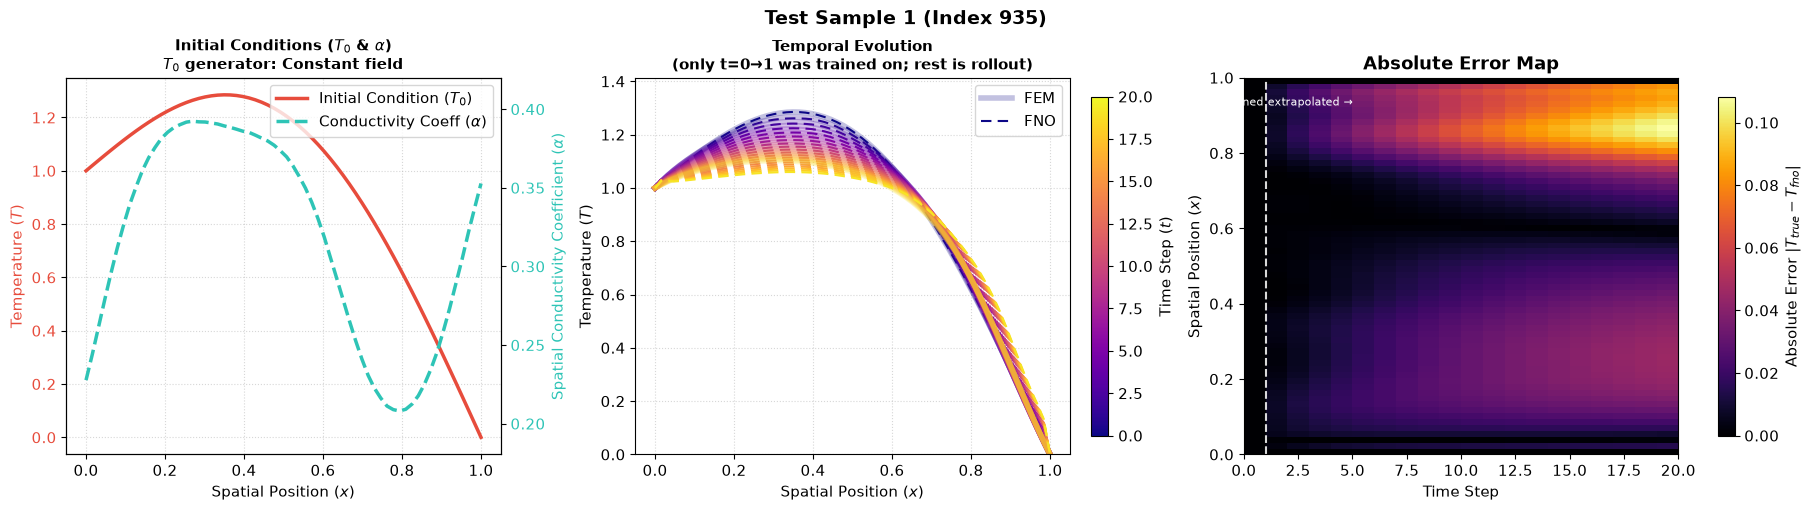

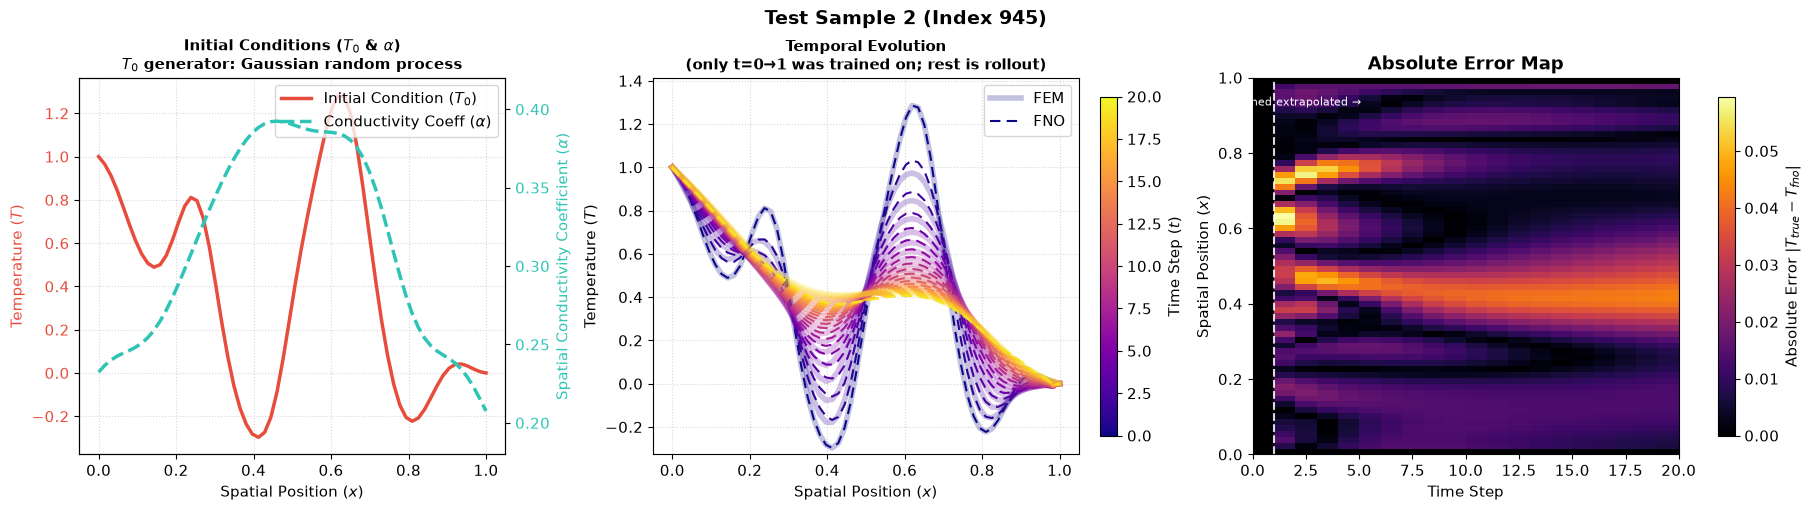

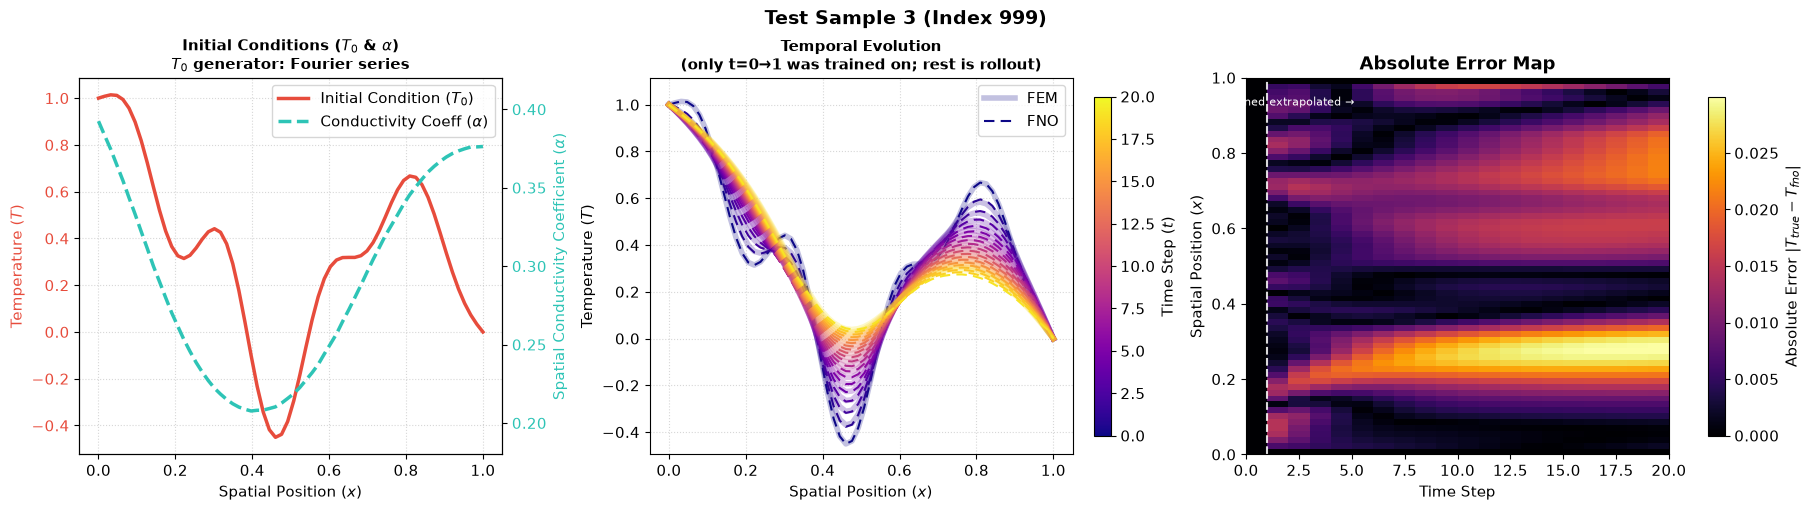

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. RANDOM TEST SELECTION ---
NUM_TEST_SAMPLES = 3  # How many random samples to visualize
test_key = jax.random.PRNGKey(42)  # Change seed for different random samples

# Define the pool (only indices unseen by training AND by early stopping --
# TRAIN_SAMPLES:ROLLOUT_TEST_START is the validation set, which the checkpoint
# was selected on and so does not belong in a qualitative "unseen" showcase)
test_pool = jnp.arange(ROLLOUT_TEST_START, N_SAMPLES)

# Choose random indices from the test pool
test_indices = jax.random.choice(test_key, test_pool, shape=(NUM_TEST_SAMPLES,), replace=False)

print(f"Randomly selected test indices: {test_indices}")

cmap = plt.get_cmap('plasma')

# --- 2. EVALUATION & VISUALIZATION LOOP ---
for i, test_idx in enumerate(test_indices):
    # Retrieve data for this random index
    T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]
    t0_gen_name = T0_GENERATOR_NAMES[int(all_T0_generator[test_idx])]
    
    # Generate trajectories (Using local scope functions). Ground truth comes
    # from the shared derived reference (Section 4), like Sections 6 and 7 --
    # not a fresh fem_rollout at N_NODES=64, which would carry a different
    # discretization error than the box plots are measured against.
    true_traj = jnp.asarray(fem_dataset["trajectory"])[test_idx, :MAX_STEPS]
    fno_pred = rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)
    fno_traj = jnp.vstack([T0_test, fno_pred])
    error_traj = jnp.abs(true_traj - fno_traj)
    
    # Create Figure: 1 Row, 3 Columns using constrained layout to prevent overlap warnings
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary Axis: Temperature Profile
    line1 = ax1.plot(GRID, T0_test, color='#e74c3c', lw=2.5, label="Initial Condition ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Secondary Axis: Spatial Conductivity Coefficient Profile
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_test, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Scale secondary axis limits cleanly to fit the dynamic alpha range
    alpha_min, alpha_max = jnp.min(alpha_test), jnp.max(alpha_test)
    alpha_range = abs(alpha_max - alpha_min) if alpha_max != alpha_min else float(alpha_max) * 0.1
    ax1_twin.set_ylim(float(alpha_min) - alpha_range * 0.15, float(alpha_max) + alpha_range * 0.15)
    
    # Combined Legend for both traces
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    # T0 generator is labeled explicitly (not guessed from the curve's shape) --
    # min-max normalization forces every sample, regardless of generator, to
    # span the full [-1,1] perturbation range, so a single Fourier or GRF draw
    # can look "extreme" without that implying it came from a different family.
    ax1.set_title(f"Initial Conditions ($T_0$ & $\\alpha$)\n$T_0$ generator: {t0_gen_name}", fontweight='bold', fontsize=11)
    
    # --- COL 2: TEMPERATURE EVOLUTION (LINE PLOTS) ---
    # Only the t=0 (T0, solid) -> t=1 (dashed) transition is what the network
    # was actually trained on; every later curve (t=2 onward) is produced by
    # feeding the FNO's own prior prediction back in autoregressively, so it's
    # rollout into territory the physics residual never saw during training.
    plot_steps = range(0, MAX_STEPS, 1)  # Plotting every step
    for t in plot_steps:
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.25, lw=4, label="FEM" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls=(0, (5, 3)), lw=1.5, label="FNO" if t==0 else "")
        
    ax2.set_title("Temporal Evolution\n(only t=0→1 was trained on; rest is rollout)", fontweight='bold', fontsize=11)
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # Dynamic Y-Limit for Temperature
    y_min, y_max = jnp.min(true_traj), jnp.max(true_traj)
    ax2.set_ylim(y_min - abs(y_min)*0.1, y_max + abs(y_max)*0.1)

    # Dedicated Colorbar for Evolution lines
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_traj.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.axvline(x=1, color='white', linestyle='--', lw=1.5, alpha=0.85)
    ax3.text(0.9, 0.95, 'trained', color='white', fontsize=8, va='top', ha='right')
    ax3.text(1.1, 0.95, 'extrapolated →', color='white', fontsize=8, va='top', ha='left')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for the Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error $|T_{true} - T_{fno}|$')

    fig.suptitle(f"Test Sample {i+1} (Index {test_idx})", fontsize=14, fontweight='bold')
    plt.show()

## 11. Out-of-distribution stress test: 50 unseen shapes × 6 resolutions

The operator is challenged along **two independent OOD axes at once**:

- **Shape.** 50 initial fields from four families never seen in training: *Staircase* (smoothed step, random position and width), *Pyramid* (random peak), *Asymmetric* (random two-harmonic mix) and *HF-Rand* (random high-frequency Fourier content). They are split 13 / 13 / 12 / 12, all at constant $\alpha=0.25$.
- **Resolution.** Each shape is evaluated at the training resolution $N=64$ and at $N=96,128,160,192,256$ (super-resolution), which gives 300 evaluations in total.

The ground truth is `fem_ground_truth.py`'s OOD reference. Each shape is solved once at $N=512$, $\Delta t=0.001$, then interpolated and sub-sampled to each resolution, so every resolution is graded against the same converged answer. This only works because `fno_model` reads the mesh size and mask from its input. The spectral and pointwise layers are resolution-agnostic by construction, so the super-resolution part is a genuine test of the operator-learning claim.

A few representative examples are shown in full first (initial condition, evolution snapshots, error map). Then all evaluations are summarized as a box plot styled like Section 9's, followed by a per-resolution breakdown.

Loaded fine OOD reference: 50 shapes (13 Staircase, 13 Pyramid, 12 Asymmetric, 12 HF-Rand)
Evaluating FNO rollout for 50 shapes x 6 resolutions = 300 scenarios...


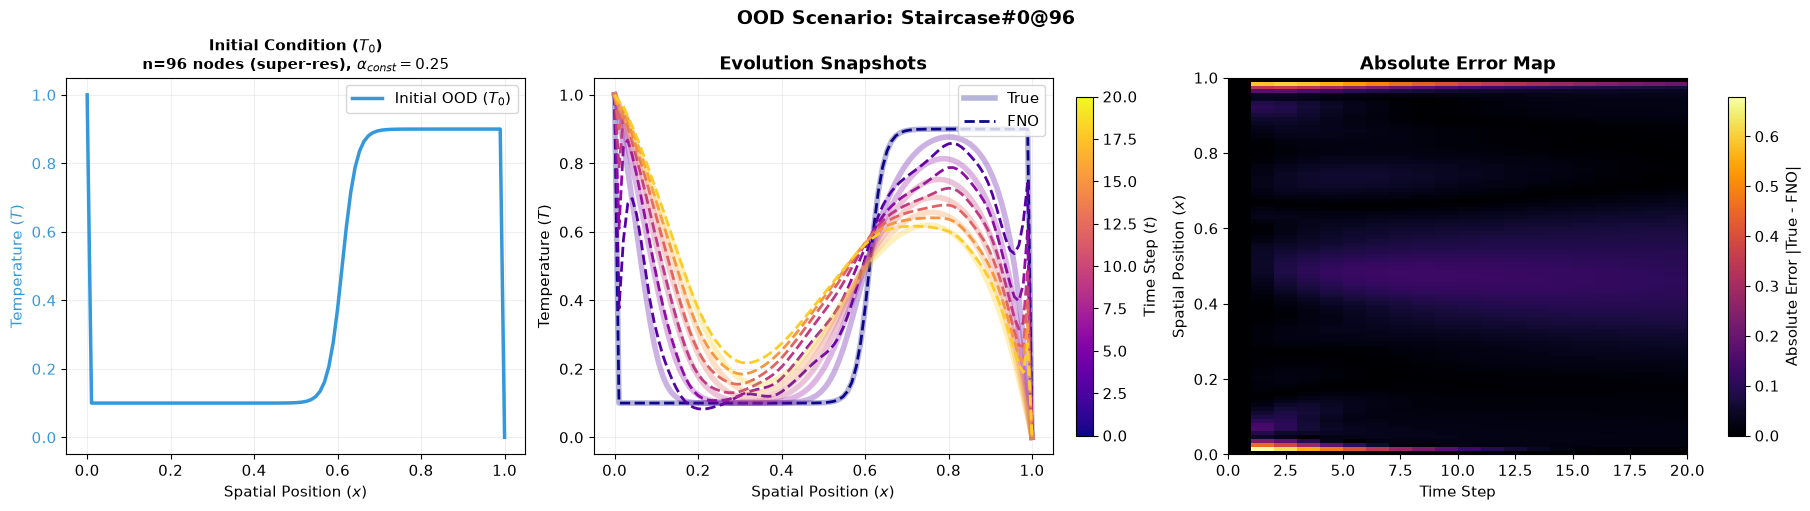

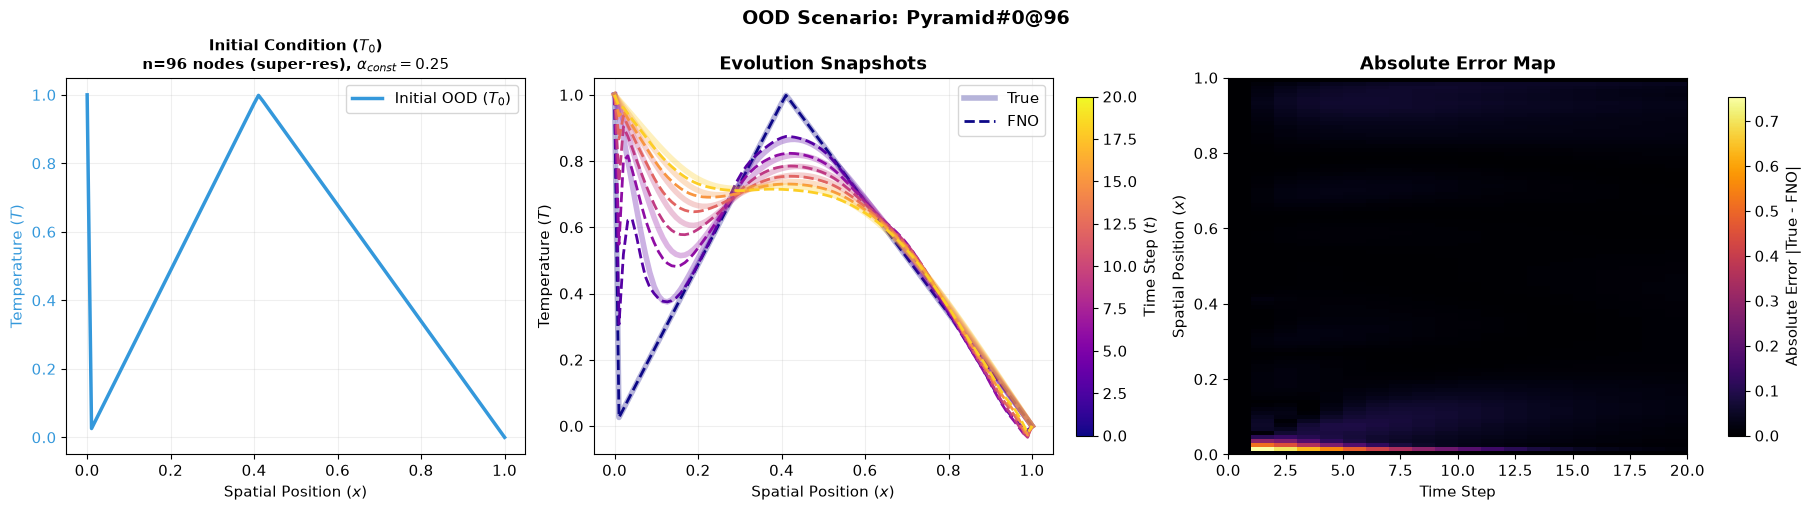

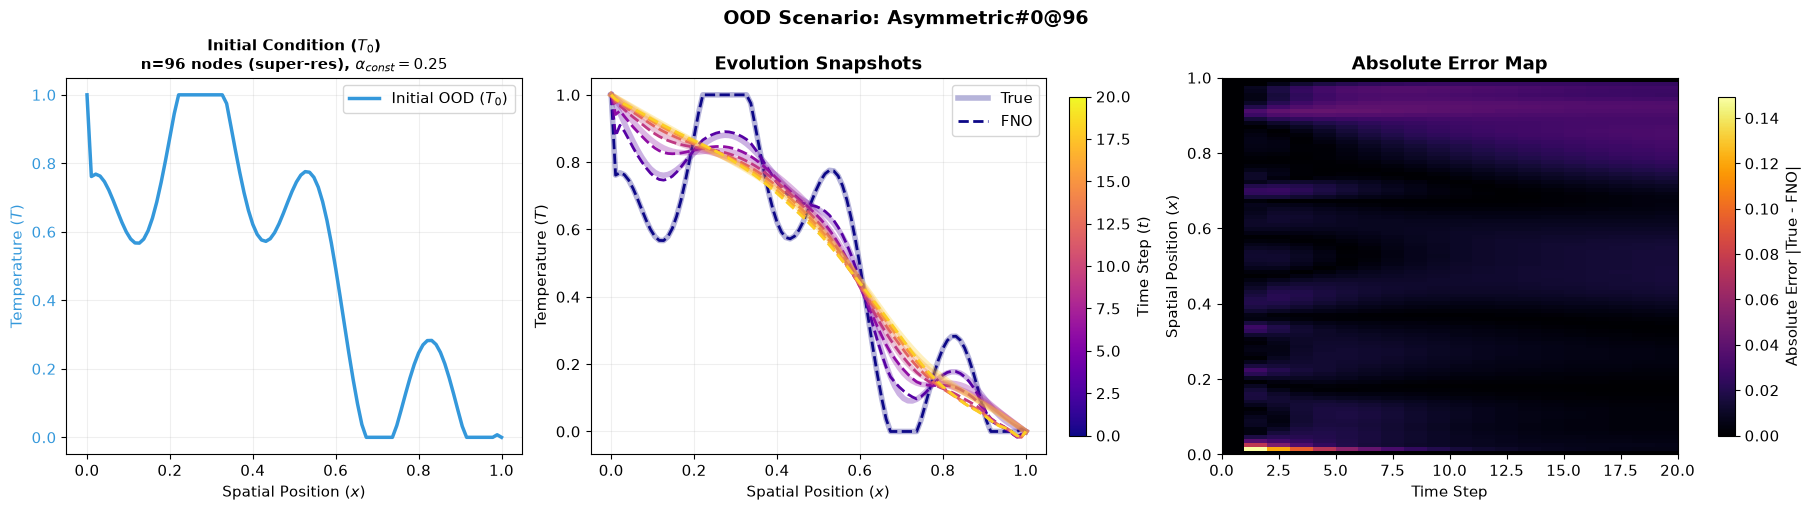

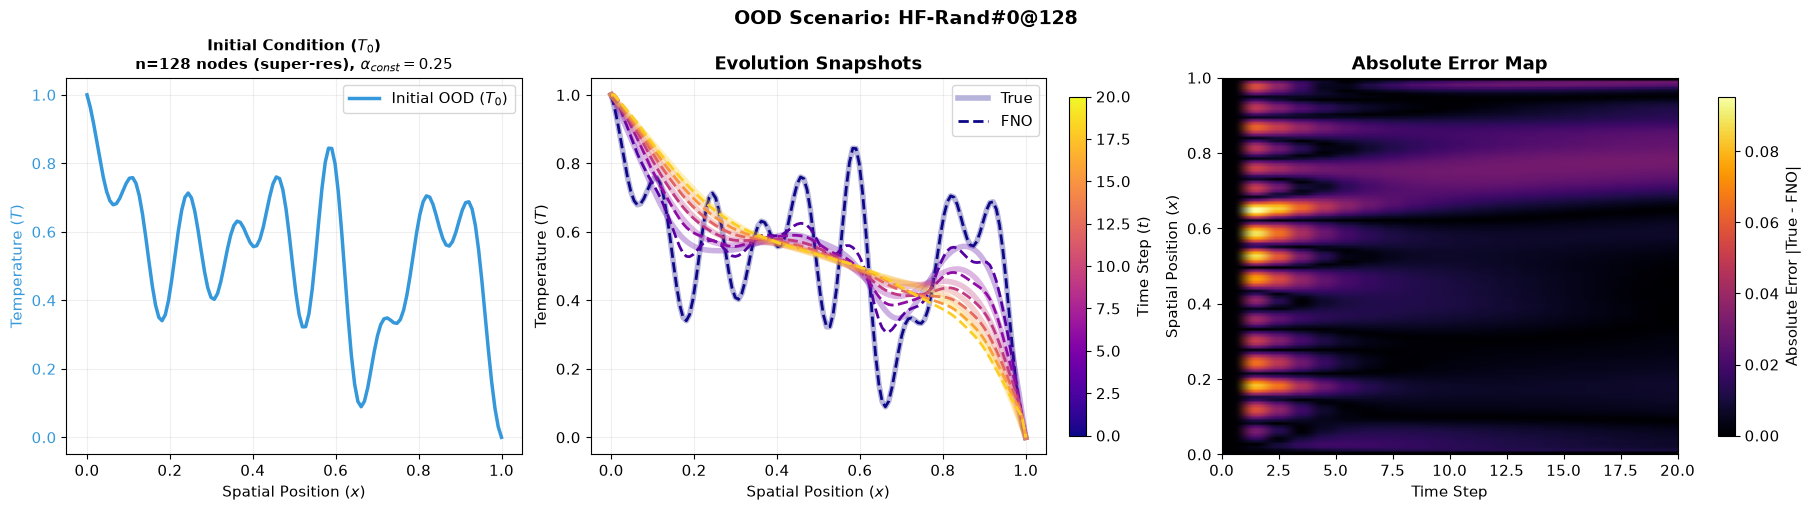

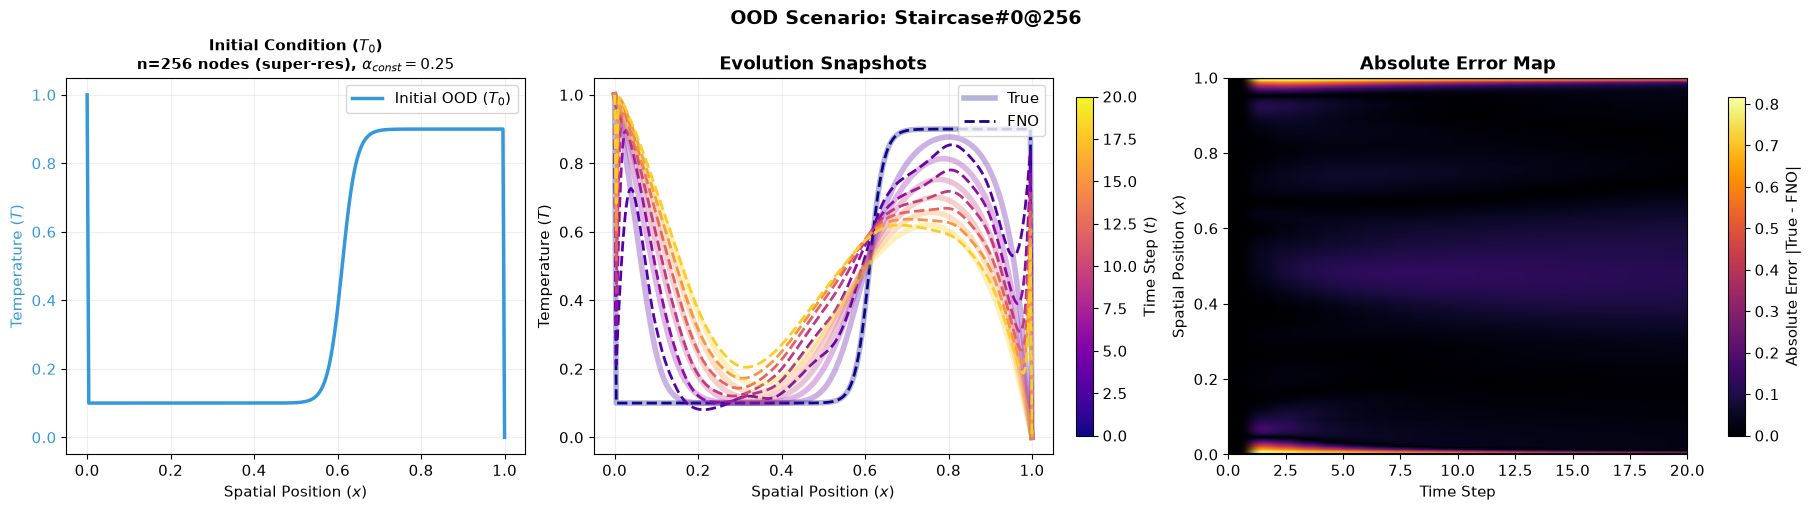

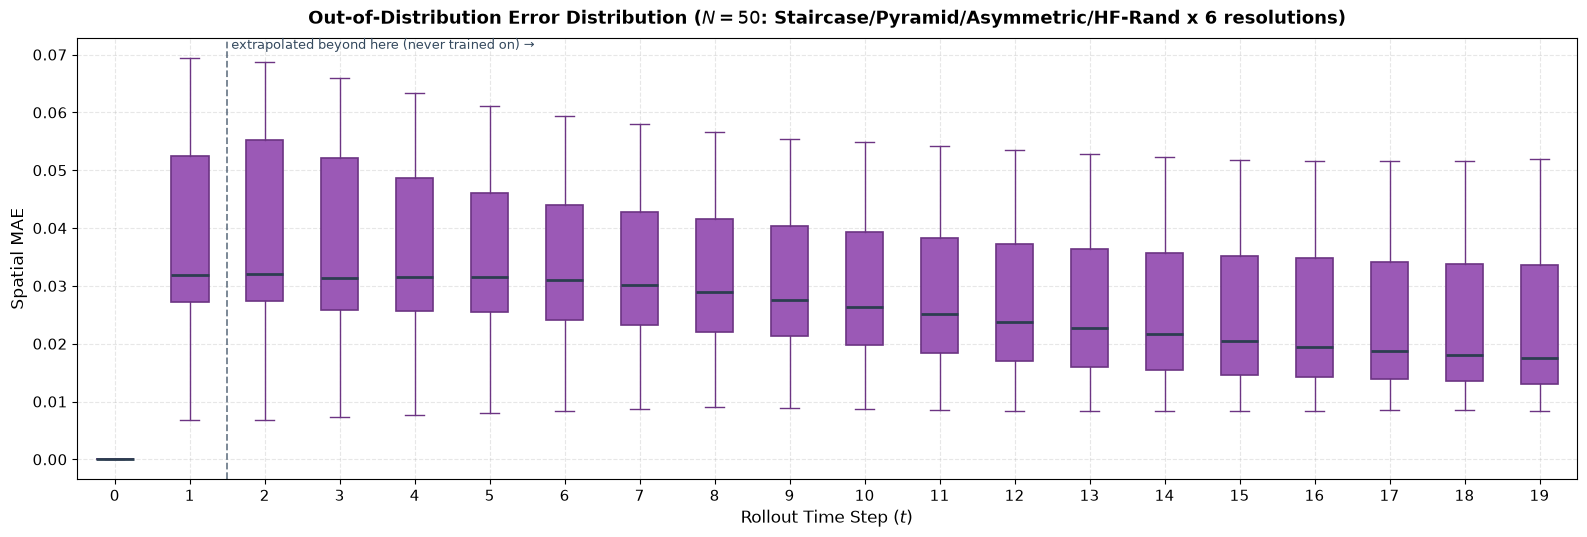


Mean rollout MAE by resolution (averaged over all time steps and shape families):
  N=  64 (training res): mean=2.3659e-02  (n=50 scenarios)
  N=  96 (super-res): mean=2.6276e-02  (n=50 scenarios)
  N= 128 (super-res): mean=2.7994e-02  (n=50 scenarios)
  N= 160 (super-res): mean=2.9170e-02  (n=50 scenarios)
  N= 192 (super-res): mean=3.0007e-02  (n=50 scenarios)
  N= 256 (super-res): mean=3.1112e-02  (n=50 scenarios)


In [6]:
# ==========================================
# 9. OOD STRESS TEST -- 50 SCENARIOS (SPLIT ACROSS SHAPE) x 6 RESOLUTIONS
# ==========================================
# Ground truth now comes from the universal OOD reference solved ONCE on the
# GPU (fem_universal_reference_precompute.py: N=512, dt=0.001, 400 steps,
# float64), not from fresh per-resolution solves. get_ood_fine_trajectories
# loads that already-solved pool of 50 shapes (13 Staircase + 13 Pyramid +
# 12 Asymmetric + 12 HF-Rand, each solved once at the fine mesh -- Staircase/
# Pyramid/Asymmetric are now randomized too: transition position/width, peak
# position, freqs/amps respectively, not one fixed shape each); derive_ood_dataset
# then interpolates/subsamples that ONE solve down to any (n_nodes, dt) with NO
# further FEM solving -- so it's cheap to evaluate the same 50 shapes at every
# resolution below instead of only assigning each shape to one resolution.

from fem_ground_truth import get_ood_fine_trajectories, derive_ood_dataset

OOD_RES_CHOICES = [N_NODES, 96, 128, 160, 192, 256]
N_OOD = 50

# Absolute, like Section 4's cache paths: a relative path here is a silent cache
# MISS if the kernel's cwd is not the notebook folder -- get_ood_fine_trajectories
# would quietly re-solve 50 shapes at N=512 x 400 steps instead of raising.
OOD_REFERENCE_PATH = os.path.join(_CKPT_DIR, "ood_fine_reference.pkl")
ood_ref = get_ood_fine_trajectories(OOD_REFERENCE_PATH, n_total=N_OOD, dt_ref=0.001, steps_ref=400,
                                     reference_n_nodes=512)
family_counts = ", ".join(f"{ood_ref['families'].count(fam)} {fam}" for fam in dict.fromkeys(ood_ref["families"]))
print(f"Loaded fine OOD reference: {len(ood_ref['labels'])} shapes ({family_counts})")

# Each of the 50 shapes evaluated at each of the 6 resolutions -- 300 total
# (label, resolution) evaluations, all derived from the one fine reference
# solve above (no re-solving per resolution). true_traj comes straight out of
# derive_ood_dataset; only the FNO rollout still needs to be run here.
print(f"Evaluating FNO rollout for {N_OOD} shapes x {len(OOD_RES_CHOICES)} resolutions "
      f"= {N_OOD * len(OOD_RES_CHOICES)} scenarios...")
ood_results = []   # (label, family, res, T0, true_traj, fno_traj)
for res in OOD_RES_CHOICES:
    derived = derive_ood_dataset(ood_ref, n_nodes_target=res, dt_target=DT)
    grid_local = jnp.linspace(0, 1, res)
    for scen in derived:
        T0_local, alpha_local = jnp.asarray(scen["T0"]), jnp.asarray(scen["alpha"])
        # derive_ood_dataset's dt=0.02 stride covers steps 0..20 (t=0..0.4, 21
        # states); trim to MAX_STEPS=20 (t=0..0.38) to match the FNO rollout below.
        true_traj_local = jnp.asarray(scen["true_traj"])[:MAX_STEPS]
        fno_traj_local = jnp.vstack([T0_local, rollout_fno_res(params, T0_local, alpha_local, grid_local, MAX_STEPS - 1)])
        ood_results.append((f"{scen['label']}", scen["family"], res, T0_local, true_traj_local, fno_traj_local))

# =====================================================================
# 9a. REPRESENTATIVE EXAMPLES -- one per fixed family plus one HF-Rand
#     draw, all at training resolution, plus one extra at super-resolution
# =====================================================================
picks = []
for fname in ["Staircase", "Pyramid", "Asymmetric"]:
    picks.append(next(r for r in ood_results if r[1] == fname and r[2] == 96))
picks.append(next(r for r in ood_results if r[1].startswith("HF-Rand") and r[2] == 128))
picks.append(next(r for r in ood_results if r[2] == 256))   # one super-res example too

cmap = plt.get_cmap('plasma')
for label, fname, res, T0_local, true_traj_local, fno_traj_local in picks:
    grid_local = jnp.linspace(0, 1, res)
    error_map = jnp.abs(true_traj_local - fno_traj_local)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")

    ax1.plot(grid_local, T0_local, color='#3498db', lw=2.5, label="Initial OOD ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')
    ax1.grid(True, alpha=0.2)
    ax1.legend(loc="upper right")
    ax1.set_title(f"Initial Condition ($T_0$)\nn={res} nodes ({'training res' if res == N_NODES else 'super-res'}), "
                   f"$\\alpha_{{const}}=0.25$", fontweight='bold', fontsize=11)

    for t in range(0, MAX_STEPS, MAX_STEPS // 6):
        color = cmap(t / MAX_STEPS)
        ax2.plot(grid_local, true_traj_local[t], color=color, alpha=0.3, lw=4, label="True" if t == 0 else "")
        ax2.plot(grid_local, fno_traj_local[t], color=color, ls='--', lw=2, label="FNO" if t == 0 else "")
    ax2.set_title("Evolution Snapshots", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)"); ax2.set_ylabel("Temperature ($T$)")
    ax2.legend(loc="upper right"); ax2.grid(True, alpha=0.2)
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9); cbar2.set_label('Time Step ($t$)')

    im3 = ax3.imshow(error_map.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step"); ax3.set_ylabel("Spatial Position ($x$)")
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9); cbar3.set_label('Absolute Error |True - FNO|')

    fig.suptitle(f"OOD Scenario: {label}", fontsize=14, fontweight='bold')
    plt.show()

# =====================================================================
# 9b. AGGREGATE -- box plot over all 50 scenarios (styled like Section 7's)
# =====================================================================
mae_ood_np = np.stack([np.asarray(jnp.mean(jnp.abs(true_t - fno_t), axis=1))
                        for (_, _, _, _, true_t, fno_t) in ood_results])   # (N_OOD, MAX_STEPS)

n_steps = mae_ood_np.shape[1]
steps = np.arange(n_steps)

fig, ax = plt.subplots(figsize=(16, 5.5))
box_ood = dict(facecolor='#9b59b6', color='#6c3483', linewidth=1.2)
median_props = dict(color='#2c3e50', linewidth=2)
flier_props = dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', markeredgecolor='none', alpha=0.2)
ax.boxplot(mae_ood_np, positions=steps, patch_artist=True, boxprops=box_ood,
           whiskerprops=dict(color='#6c3483'), capprops=dict(color='#6c3483'),
           medianprops=median_props, flierprops=flier_props)
ax.axvline(x=1.5, color='#34495e', linestyle='--', lw=1.3, alpha=0.7)
ax.text(1.5, ax.get_ylim()[1], ' extrapolated beyond here (never trained on) →',
        color='#34495e', fontsize=9, va='top', ha='left')
ax.set_title(f"Out-of-Distribution Error Distribution ($N={N_OOD}$: Staircase/Pyramid/Asymmetric/HF-Rand "
             f"x {len(OOD_RES_CHOICES)} resolutions)", fontweight='bold', fontsize=13, pad=10)
ax.set_xlabel("Rollout Time Step ($t$)", fontsize=12)
ax.set_ylabel("Spatial MAE", fontsize=12)
ax.set_xticks(steps); ax.set_xticklabels([str(s) for s in steps])
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Break down error by resolution, to see whether super-resolution specifically
# (as opposed to shape novelty) degrades accuracy -- averaged over full rollout.
mae_by_res = {res: [] for res in OOD_RES_CHOICES}
for (label, fname, res, T0_local, true_t, fno_t), mae_traj in zip(ood_results, mae_ood_np):
    mae_by_res[res].append(mae_traj.mean())
print("\nMean rollout MAE by resolution (averaged over all time steps and shape families):")
for res in OOD_RES_CHOICES:
    vals = mae_by_res[res]
    print(f"  N={res:4d} ({'training res' if res == N_NODES else 'super-res'}): "
          f"mean={np.mean(vals):.4e}  (n={len(vals)} scenarios)")

## 12. Discussion

- **Label-free training works.** Without a single FEM trajectory in training, and seeing only the first transition of each sample, the operator follows the reference over all 19 steps. Its first-step error is close to the discretization floor of the training grid ([The Benchmark Problem](benchmark_problem.ipynb), Section 7), and the error grows only slowly as the rollout extrapolates into states it was never trained on.
- **Generalization.** On unseen initial shapes and finer grids the error stays of the same order as in distribution, and it decreases along the rollout, as diffusion smooths the unfamiliar initial field toward the kind of state seen in training. The [transient comparison](transient_comparison.ipynb) shows this is the strongest out-of-distribution result of the three transient operators.
- **The price is a fixed time step.** The backward-Euler step with $\Delta t = 0.02$ is built into the training residual, so the trained weights are tied to that $\Delta t$ and must be retrained for any other.

The next chapter, [Physics-Informed Time-Integrated Operator (PITI-FNO)](FNO_transient_PITI.ipynb), removes that coupling by learning the time derivative itself, so that the time step and the integrator can be chosen at inference.